In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances
%matplotlib inline

In [11]:
n_samples = 100
random_state = 170
center_points = [[1, 1], [-1, -1], [1, -1]] # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định
#center_points = 3 # tâm cụm được chọn ngẫu nhiên
X, y = make_blobs(n_samples=n_samples, random_state=random_state,centers=center_points, cluster_std=0.6)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:6])


Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]
 [ 2.67199591 -0.16659988]]


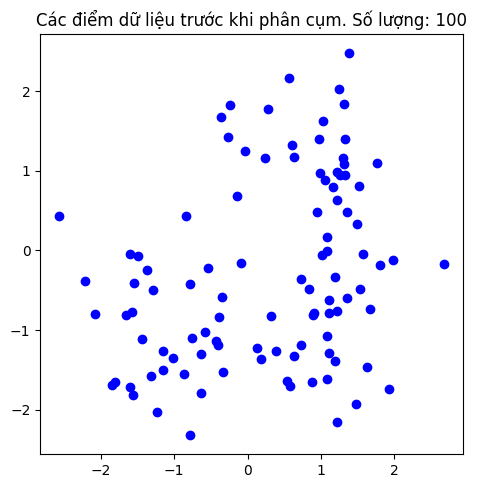

In [12]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()


In [13]:
def K_means(X, n_clusters, max_iters=100):
    np.random.seed(42)
    n_samples, n_features = X.shape
    # Khởi tạo ngẫu nhiên các tâm cụm từ dữ liệu    
    initial_indices = np.random.choice(n_samples, n_clusters, replace=False)
    centers = X[initial_indices]    

    for _ in range(max_iters):
        # Tính khoảng cách từ mỗi điểm dữ liệu đến các tâm cụm
        distances = euclidean_distances(X, centers)
        # Gán nhãn cho mỗi điểm dữ liệu dựa trên tâm cụm gần nhất
        labels = np.argmin(distances, axis=1)        
        # Cập nhật vị trí của các tâm cụm
        new_centers = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])        
        # Kiểm tra điều kiện dừng (nếu tâm cụm không thay đổi)
        if np.all(centers == new_centers):
            break
        centers = new_centers
    return centers, labels

Text(0.5, 1.0, 'K-means clustering')

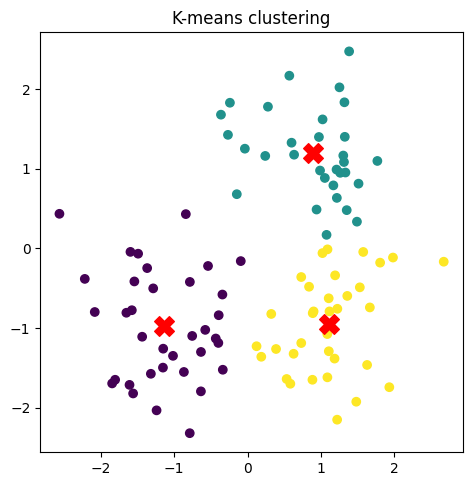

In [14]:
centers, labels = K_means(X, n_clusters=3)
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200) # vẽ các tâm cụm
plt.title("K-means clustering")

Text(0.5, 1.0, 'K-means clustering (sklearn)')

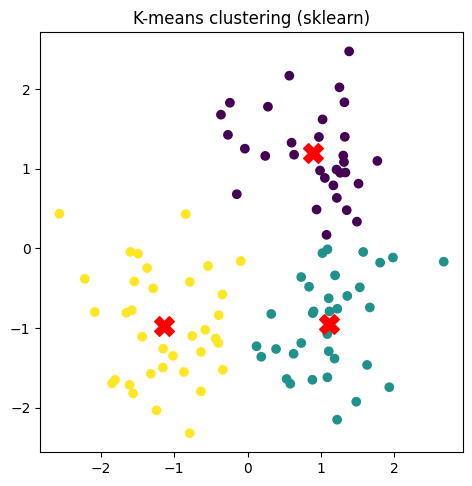

In [15]:
# Kmeans từ thư viện sklearn
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200) # vẽ các tâm cụm
plt.title("K-means clustering (sklearn)")